In [ ]:
import pandas as pd
import numpy as np
from sklearn import linear_model

In [ ]:
d = pd.read_csv("StudentPerformance.csv")
d

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0


In [ ]:
d.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [ ]:
d['Extracurricular Activities']=d['Extracurricular Activities'].map({'Yes':1,'No':0})
d

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,1,4,2,23.0
9996,7,64,1,8,5,58.0
9997,6,83,1,8,5,74.0
9998,9,97,1,7,0,95.0


In [ ]:
d.shape

(10000, 6)

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x = d[['Hours Studied','Previous Scores','Extracurricular Activities','Sleep Hours','Sample Question Papers Practiced']]
y = d['Performance Index']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state= 42)

In [ ]:
x_train.shape, y_train.shape

((8000, 5), (8000,))

In [ ]:
x_test.shape, y_test.shape

((2000, 5), (2000,))

In [ ]:
df = d.sample(frac=0.2, random_state=42)

In [ ]:
df

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
6252,5,69,0,8,2,51.0
4684,2,46,1,4,8,20.0
1731,7,56,1,7,5,46.0
4742,6,42,1,8,5,28.0
4521,7,53,0,4,6,41.0
...,...,...,...,...,...,...
6412,2,70,0,7,3,45.0
8285,4,79,0,9,3,66.0
7853,2,40,1,7,2,16.0
1095,3,83,0,7,5,65.0


In [ ]:
df.shape

(2000, 6)

In [ ]:
df.describe()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,5.031500,69.104500,0.495500,6.486500,4.45050,54.878000
std,2.567256,17.340961,0.500105,1.685004,2.88855,19.255402
min,1.000000,40.000000,0.000000,4.000000,0.00000,11.000000
25%,3.000000,54.000000,0.000000,5.000000,2.00000,40.000000
50%,5.000000,68.000000,0.000000,7.000000,4.00000,55.000000
75%,7.000000,84.000000,1.000000,8.000000,7.00000,70.000000
max,9.000000,99.000000,1.000000,9.000000,9.00000,99.000000


In [ ]:
import seaborn as sns

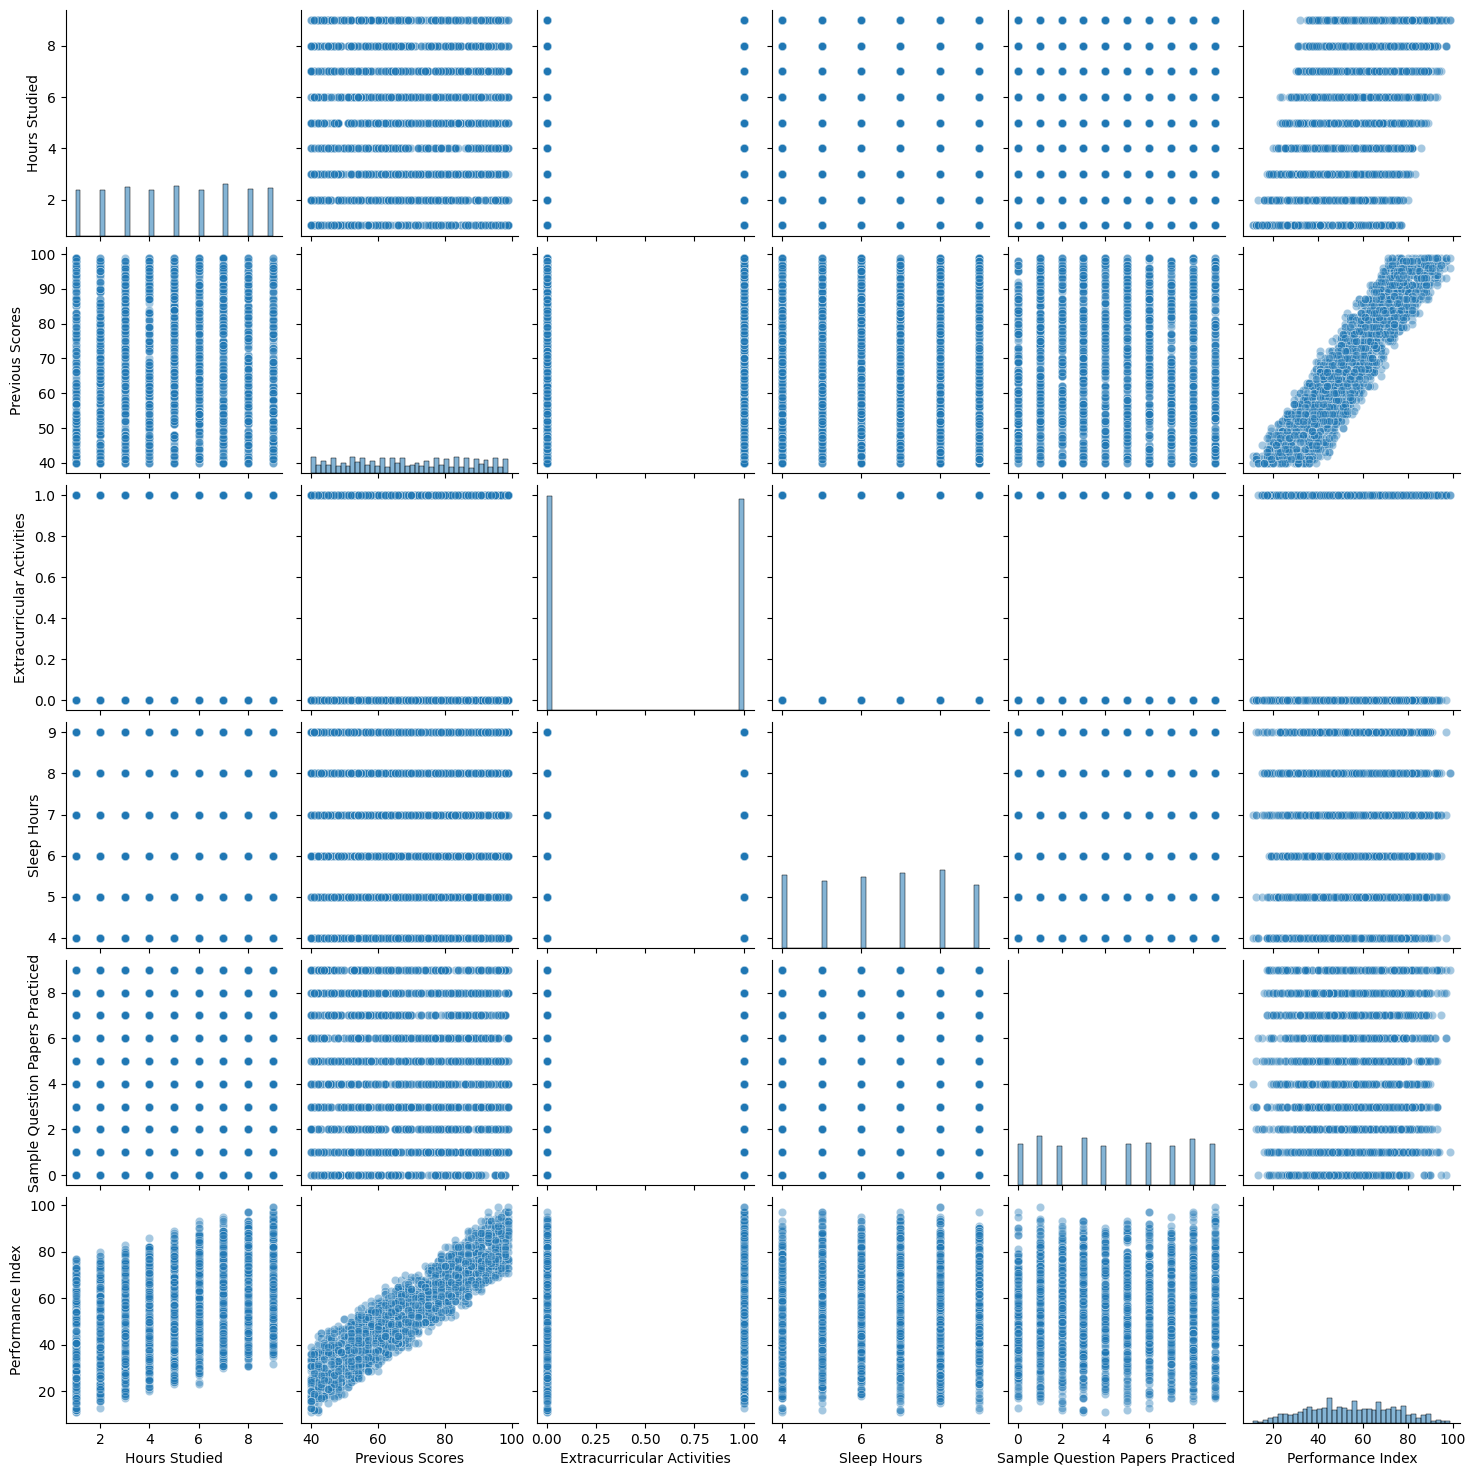

In [ ]:
sns.pairplot(df,
             kind='scatter',
             plot_kws={'alpha':0.4},
             diag_kws={'alpha':0.55, 'bins':40})

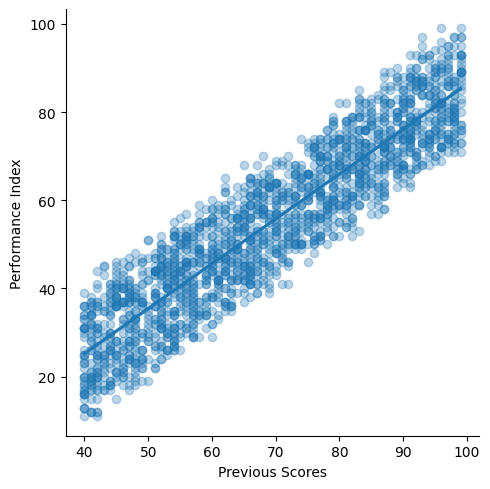

In [ ]:
sns.lmplot(x='Previous Scores',
           y='Performance Index',
           data=df,
           scatter_kws={'alpha':0.3})

In [ ]:
reg = linear_model.LinearRegression()
reg.fit(x_train,y_train)

LinearRegression()

In [ ]:
data=pd.DataFrame([[6,89,0,7,3]], columns=['Hours Studied', 'Previous Scores', 'Extracurricular Activities', 'Sleep Hours', 'Sample Question Papers Practiced'])
data

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
0,6,89,0,7,3


In [ ]:
reg.coef_

array([2.85248393, 1.0169882 , 0.60861668, 0.47694148, 0.19183144])

In [ ]:
cf = pd.DataFrame(reg.coef_,x.columns, columns=['Coefficient'])
cf

,Coefficient
Hours Studied,2.852484
Previous Scores,1.016988
Extracurricular Activities,0.608617
Sleep Hours,0.476941
Sample Question Papers Practiced,0.191831


In [ ]:
reg.intercept_

np.float64(-33.92194621555638)

y= (m1*x1+m2*x2+m3*x3+m4*x4+m5*x5)+ b

In [ ]:
2.85248393*6 + 1.0169882*89 + 0 +  0.47694148*7 + 0.19183144*3 + (-33.92194621555638)

77.61899184444363

In [ ]:
import joblib
joblib.dump(reg, 'model_joblib')

['model_joblib']

In [ ]:
mj = joblib.load('model_joblib')


In [ ]:
mj.intercept_

np.float64(-33.92194621555638)

In [ ]:
mj.coef_

array([2.85248393, 1.0169882 , 0.60861668, 0.47694148, 0.19183144])

In [ ]:
print('performance index:', mj.predict(data))

performance index: [77.61899178]


In [ ]:
predictions= mj.predict(x_test)
predictions

array([54.71185392, 22.61551294, 47.90314471, ..., 16.79341955,
       63.34327368, 45.94262301])

Text(0.5, 1.0, 'performance vs predictions')

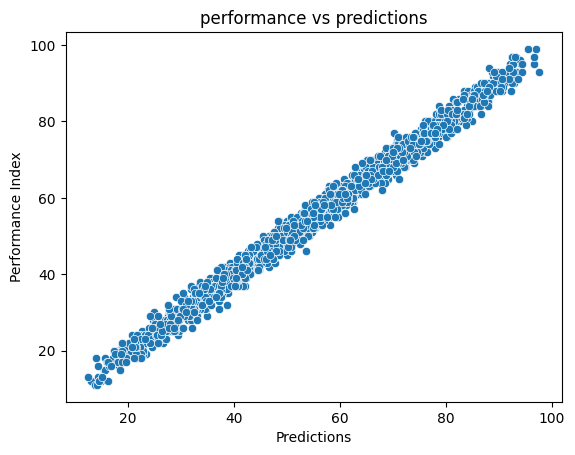

In [ ]:
import matplotlib.pyplot as plt
sns.scatterplot(x= predictions,y= y_test)
plt.xlabel('Predictions')
plt.title('performance vs predictions')

In [ ]:
residuals = y_test-predictions

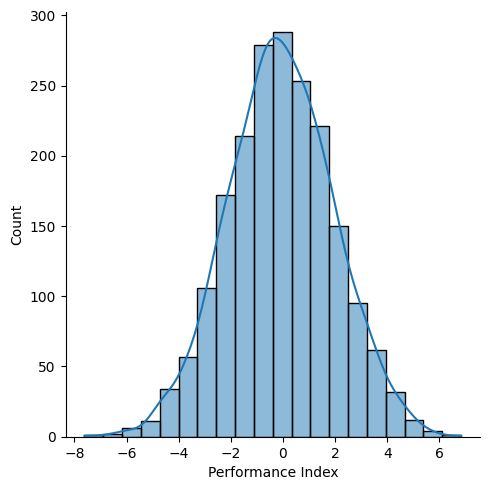

In [ ]:
sns.displot(residuals, bins = 20, kde =True)

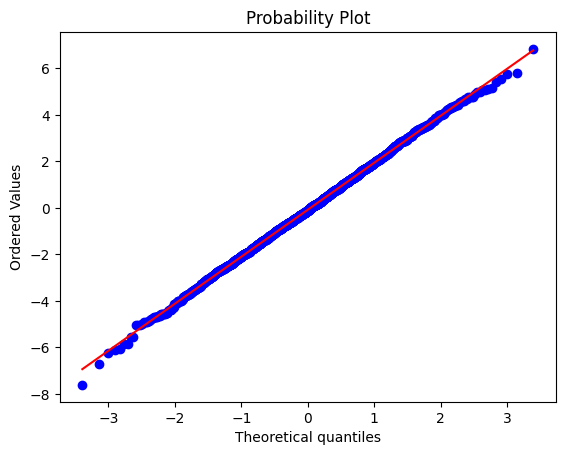

In [ ]:
import pylab
import scipy.stats as stats

stats.probplot(residuals, dist="norm", plot=pylab)
pylab.show()

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math

In [ ]:
print('Mean Absolute Error:',mean_absolute_error(y_test, predictions))
print('Mean Squared Error:',mean_squared_error(y_test, predictions))
print('Root Mean Squared Error:',math.sqrt(mean_squared_error(y_test, predictions)))

Mean Absolute Error: 1.6111213463123044
Mean Squared Error: 4.082628398521853
Root Mean Squared Error: 2.0205515085050054


In [ ]:
mj.score(x_test,y_test)

0.9889832909573145

# Task
Create a markdown cell that describes the linear regression project, its objective of predicting student performance, and lists the Python libraries used (pandas, numpy, scikit-learn, seaborn, matplotlib, joblib, scipy, and math), explaining each library's role and specific functions within the project.

## Generate About Section

### Subtask:
Create a markdown cell that describes the linear regression project, its objective of predicting student performance, and lists the Python libraries used. For each library, briefly explain its role and specific functions within the context of this project (e.g., pandas for data manipulation, scikit-learn for model building, seaborn/matplotlib for visualization, joblib for model persistence).


## Student Performance Prediction using Linear Regression

### Project Objective
The objective of this project is to build a linear regression model to predict student performance based on various influencing factors such as hours studied, previous scores, extracurricular activities, sleep hours, and the number of sample question papers practiced.

### Python Libraries Used
This project leverages several Python libraries, each playing a crucial role:

-   **pandas**: Used for efficient data manipulation and analysis. Specific functions include reading the CSV file (`pd.read_csv`), inspecting data characteristics (`.head()`, `.shape`, `.describe()`), transforming categorical variables (`.map()`), and sampling data (`.sample()`) for exploratory analysis.
-   **numpy**: A fundamental package for numerical computing in Python. It provides support for large, multi-dimensional arrays and matrices, and high-level mathematical functions to operate on these arrays. It often serves as the numerical backbone for other libraries like pandas and scikit-learn.
-   **scikit-learn**: A comprehensive machine learning library essential for model building and evaluation. It was specifically used for splitting the dataset into training and testing sets (`train_test_split`), building and training the Linear Regression model (`linear_model.LinearRegression`), and evaluating the model's performance using metrics like `mean_absolute_error`, `mean_squared_error`, and calculating the model's `score`.
-   **seaborn**: A powerful statistical data visualization library built on top of matplotlib. In this project, it was used to create various plots, including `pairplot` for exploring relationships between all variables, `lmplot` for visualizing linear relationships between specific features, `scatterplot` for comparing predictions against actual values, and `displot` for residual analysis.
-   **matplotlib**: The foundational plotting library in Python. It was used in conjunction with seaborn for displaying and customizing plots, such as adding `plt.xlabel`, `plt.title`, and `plt.show()` to enhance readability and presentation.
-   **joblib**: Utilized for model persistence, allowing the trained linear regression model to be efficiently saved to disk (`joblib.dump`) and subsequently reloaded (`joblib.load`) for future use without the need for retraining, which is crucial for deployment scenarios.
-   **scipy**: A library for scientific computing. Specifically, its `stats` module was used to generate a probability plot (`stats.probplot`) for assessing the normality of the model's residuals, which is an important diagnostic step in regression analysis.
-   **math**: Provides access to standard mathematical functions. It was specifically used here for `math.sqrt` to calculate the Root Mean Squared Error (RMSE), a common metric for evaluating regression models.

## Final Task

### Subtask:
Present the generated 'About' section for the linear regression project.


## Summary:

### Data Analysis Key Findings
The task successfully generated a markdown cell that comprehensively describes a linear regression project aimed at predicting student performance. This description included:
*   The project's objective: To build a linear regression model predicting student performance based on factors like study hours, previous scores, extracurriculars, sleep, and practiced question papers.
*   A detailed list of eight Python libraries used, along with their specific roles and functions within the project:
    *   **pandas**: For data manipulation and analysis, including reading CSV files, inspecting data (`.head()`, `.shape`, `.describe()`), transforming categorical variables (`.map()`), and data sampling (`.sample()`).
    *   **numpy**: As the numerical computing backbone, supporting multi-dimensional arrays and mathematical functions.
    *   **scikit-learn**: For machine learning tasks, specifically data splitting (`train_test_split`), linear regression model building (`linear_model.LinearRegression`), and performance evaluation metrics (`mean_absolute_error`, `mean_squared_error`, `.score`).
    *   **seaborn**: For statistical data visualization, creating plots like `pairplot`, `lmplot`, `scatterplot`, and `displot`.
    *   **matplotlib**: The foundational plotting library, used for displaying and customizing plots (e.g., `plt.xlabel`, `plt.title`, `plt.show()`).
    *   **joblib**: For model persistence, enabling the saving (`joblib.dump`) and loading (`joblib.load`) of the trained model.
    *   **scipy**: Utilized for scientific computing, particularly its `stats` module for generating probability plots (`stats.probplot`) for residual analysis.
    *   **math**: For standard mathematical functions, such as `math.sqrt` to calculate the Root Mean Squared Error (RMSE).

### Insights or Next Steps
*   The detailed documentation of the project objective and the specific application of each library provides a clear and reproducible foundation for understanding the project's methodology and technical stack.
*   The next steps should involve executing the outlined data processing, model training, and evaluation procedures, leveraging the documented libraries and functions to achieve the project's predictive goals.
